# Heron vs Nighthawk vs Miami — 2Q Gate Count & Depth
Comparing `0002_qiskit-test-summit`, `0008_qiskit-test-summit-nighthawk`, and `0009_qiskit-test-summit-miami`.

In [13]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

BENCH_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.path.abspath('.'))),
    '.benchmarks/Darwin-CPython-3.14-64bit'
)

def load_file(filename):
    path = os.path.join(BENCH_DIR, filename)
    with open(path, encoding='utf-8') as f:
        return json.load(f)

run2      = load_file('0002_qiskit-test-summit.json')
nighthawk = load_file('0008_qiskit-test-summit-nighthawk.json')
miami     = load_file('0009_qiskit-test-summit-miami.json')

print(f"Run 2:      {run2['datetime'][:19]}") #ibm torino= heron
print(f"Nighthawk:  {nighthawk['datetime'][:19]}")
print(f"Miami:      {miami['datetime'][:19]}")

Run 2:      2026-03-13T09:46:06
Nighthawk:  2026-03-13T11:11:48
Miami:      2026-03-13T11:43:15


In [14]:
def extract_metrics(data):
    rows = {}
    for b in data['benchmarks']:
        name = b['name'].replace('_transpile', '')
        ei = b.get('extra_info', {})
        rows[name] = {
            'gate_count_2q': ei.get('output_gate_count_2q'),
            'depth_2q': ei.get('output_depth_2q'),
        }
    return rows

metrics2  = extract_metrics(run2)
metrics_nh = extract_metrics(nighthawk)
metrics_m  = extract_metrics(miami)

# Benchmarks present in all three runs with valid data
common_names = [
    n for n in metrics2
    if n in metrics_nh and n in metrics_m
    and metrics2[n]['gate_count_2q'] is not None
    and metrics_nh[n]['gate_count_2q'] is not None
    and metrics_m[n]['gate_count_2q'] is not None
]

# Sort x-axis by run 2 gate_count_2q ascending
common_names.sort(key=lambda n: metrics2[n]['gate_count_2q'])

short_names = [n.replace('test_', '') for n in common_names]
print(f"{len(common_names)} common benchmarks (sorted by run 2 gate_count_2q):")
for n in common_names:
    print(f"  {n}: run2={metrics2[n]['gate_count_2q']:,}  "
          f"nighthawk={metrics_nh[n]['gate_count_2q']:,}  "
          f"miami={metrics_m[n]['gate_count_2q']:,}")

8 common benchmarks (sorted by run 2 gate_count_2q):
  test_circSU2_100: run2=300  nighthawk=300  miami=300
  test_circSU2_89: run2=354  nighthawk=720  miami=804
  test_BV_100: run2=515  nighthawk=531  miami=469
  test_square_heisenberg_100: run2=1,353  nighthawk=540  miami=540
  test_QAOA_100: run2=8,189  nighthawk=5,102  miami=5,121
  test_QFT_100: run2=11,778  nighthawk=7,771  miami=7,933
  test_clifford_100: run2=65,702  nighthawk=39,687  miami=39,456
  test_QV_100: run2=97,422  nighthawk=67,623  miami=67,407


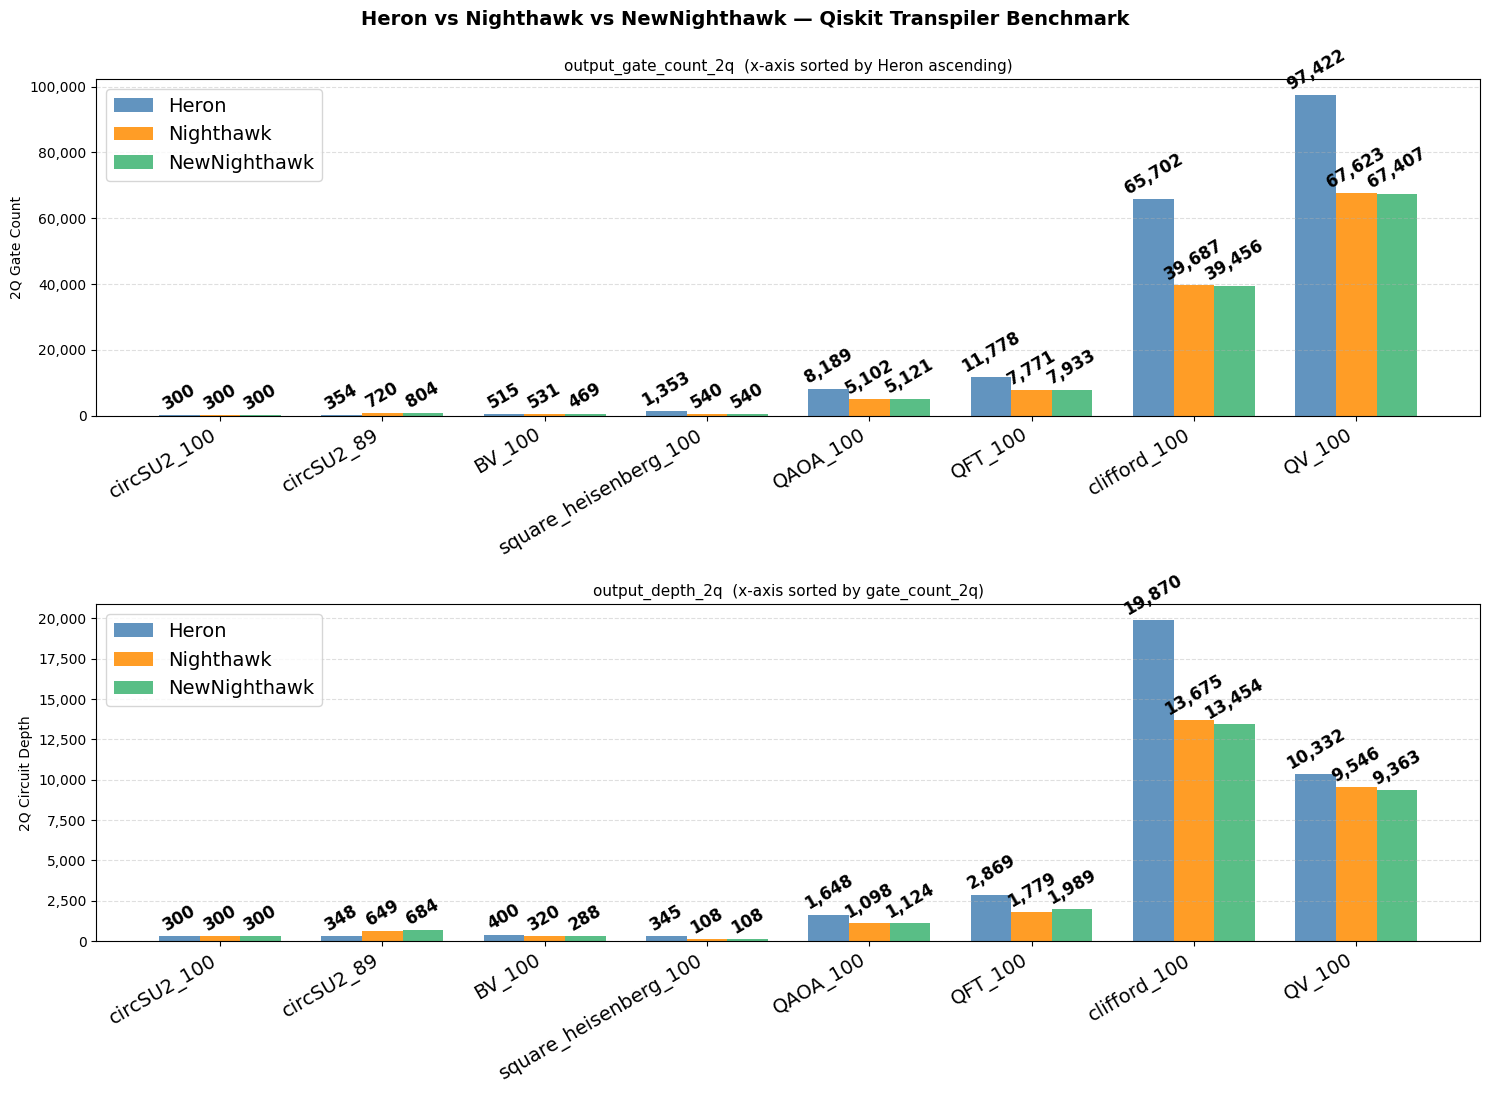

Saved: nighthawk_vs_heron.png


In [12]:
gc2   = [metrics2[n]['gate_count_2q']   for n in common_names]
gc_nh = [metrics_nh[n]['gate_count_2q']  for n in common_names]
gc_m  = [metrics_m[n]['gate_count_2q']   for n in common_names]
d2    = [metrics2[n]['depth_2q']          for n in common_names]
d_nh  = [metrics_nh[n]['depth_2q']        for n in common_names]
d_m   = [metrics_m[n]['depth_2q']         for n in common_names]

x = np.arange(len(common_names))
width = 0.25

# label2   = run2['datetime'][:16].replace('T', ' ')
# label_nh = nighthawk['datetime'][:16].replace('T', ' ')
# label_m  = miami['datetime'][:16].replace('T', ' ')

def annotate_bars(ax, bars, fontsize=12):
    for bar in bars:
        h = bar.get_height()
        if h and h > 0:
            ax.annotate(f'{int(h):,}',
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 4), textcoords='offset points',
                        ha='center', fontsize=fontsize, fontweight='bold',rotation=30,)

fig, axes = plt.subplots(2, 1, figsize=(15, 11))
fig.suptitle('Heron vs Nighthawk vs NewNighthawk — Qiskit Transpiler Benchmark',
             fontsize=14, fontweight='bold', y=0.99)

# --- 2Q Gate Count ---
ax = axes[0]
b2  = ax.bar(x - width, gc2,   width, label=f'Heron',         color='steelblue',      alpha=0.85)
bnh = ax.bar(x,          gc_nh, width, label=f'Nighthawk',    color='darkorange',     alpha=0.85)
bm  = ax.bar(x + width,  gc_m,  width, label=f'NewNighthawk',         color='mediumseagreen', alpha=0.85)
ax.set_title('output_gate_count_2q  (x-axis sorted by Heron ascending)', fontsize=11)
ax.set_ylabel('2Q Gate Count')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=14)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bars in (b2, bnh, bm):
    annotate_bars(ax, bars)

# --- 2Q Depth ---
ax2 = axes[1]
b2d  = ax2.bar(x - width, d2,   width, label=f'Heron',         color='steelblue',      alpha=0.85)
bnhd = ax2.bar(x,          d_nh, width, label=f'Nighthawk',    color='darkorange',     alpha=0.85)
bmd  = ax2.bar(x + width,  d_m,  width, label=f'NewNighthawk',         color='mediumseagreen', alpha=0.85)
ax2.set_title('output_depth_2q  (x-axis sorted by gate_count_2q)', fontsize=11)
ax2.set_ylabel('2Q Circuit Depth')
ax2.set_xticks(x)
ax2.set_xticklabels(short_names, rotation=30, ha='right', fontsize=14)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax2.legend(fontsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for bars in (b2d, bnhd, bmd):
    annotate_bars(ax2, bars)

plt.tight_layout()
plt.savefig('nighthawk_vs_heron.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nighthawk_vs_heron.png')

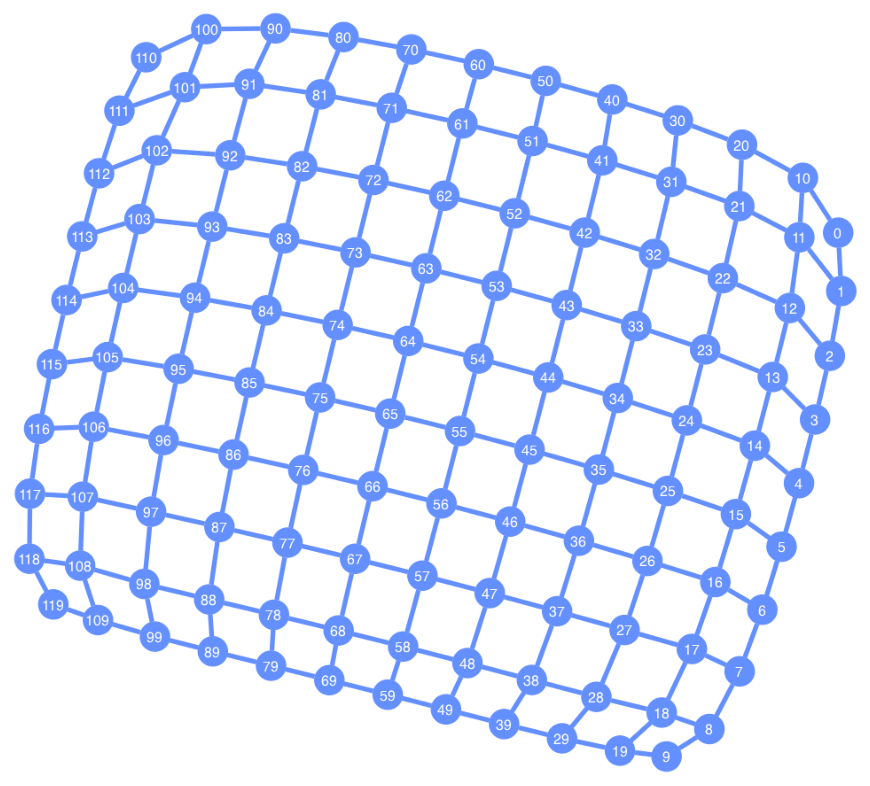

In [5]:
from qiskit.visualization import plot_gate_map
from benchpress.qiskit_gym.utils.miami.fake_miami import FakeMiami

backend = FakeMiami()
plot_gate_map(backend)


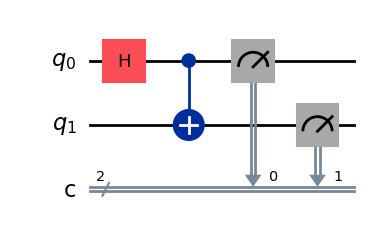

In [3]:
from qiskit import QuantumCircuit

bell = QuantumCircuit(2,2)
bell.h(0)
bell.cx(0, 1)
bell.measure([0, 1], [0, 1])

bell.draw("mpl")